## Hierarchical Bayesian Modeling For Customer Purchase Behavior

Instacart is an American company that operates a grocery delivery and pick-up service in the United States and Canada.

Instacart, a grocery ordering and delivery app aims to make it easy to fill your refrigerator and pantry with your personal favorites and staples when you need them. After selecting products through the Instacart app, personal shoppers review your order and do the in-store shopping and delivery for you. The company offers its services via a website and mobile app.

[Instacart](https://www.instacart.com/) dataset (original) contains a sample of over 3 million grocery orders from more than 200,000 Instacart users. For each user, between 4 and 100 of their orders, with the sequence of products purchased in each order. The dataset also provides the week and hour of day the order was placed, and a relative measure of time between orders.

In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    mean_squared_error, mean_absolute_error
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
aisles = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/aisles.csv')
departments = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/departments.csv')
order_products_prior = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/order_products_prior.csv')
order_products_train = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/order_products_train.csv')
orders = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/orders.csv')
products = pd.read_csv('/Volumes/T7/DS Projects/Instacart Customer Purchase Behavior/data/products.csv')

In [4]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [5]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [6]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [7]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [8]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [9]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


# Data Explanation
**orders**: This table includes all orders, namely prior, train, and test.

**order_products_train**: This table includes training orders and indicates whether a product in an order is a reorder or not (through the reordered variable).

**order_products_prior**: This table includes prior orders. It indicates whether a product in an order is a reorder or not (through the reordered variable).

**products**: This table includes all products and their related information.

**aisles**: This table includes all aisles and their related information.

**departments**: This table includes all departments and their related information.


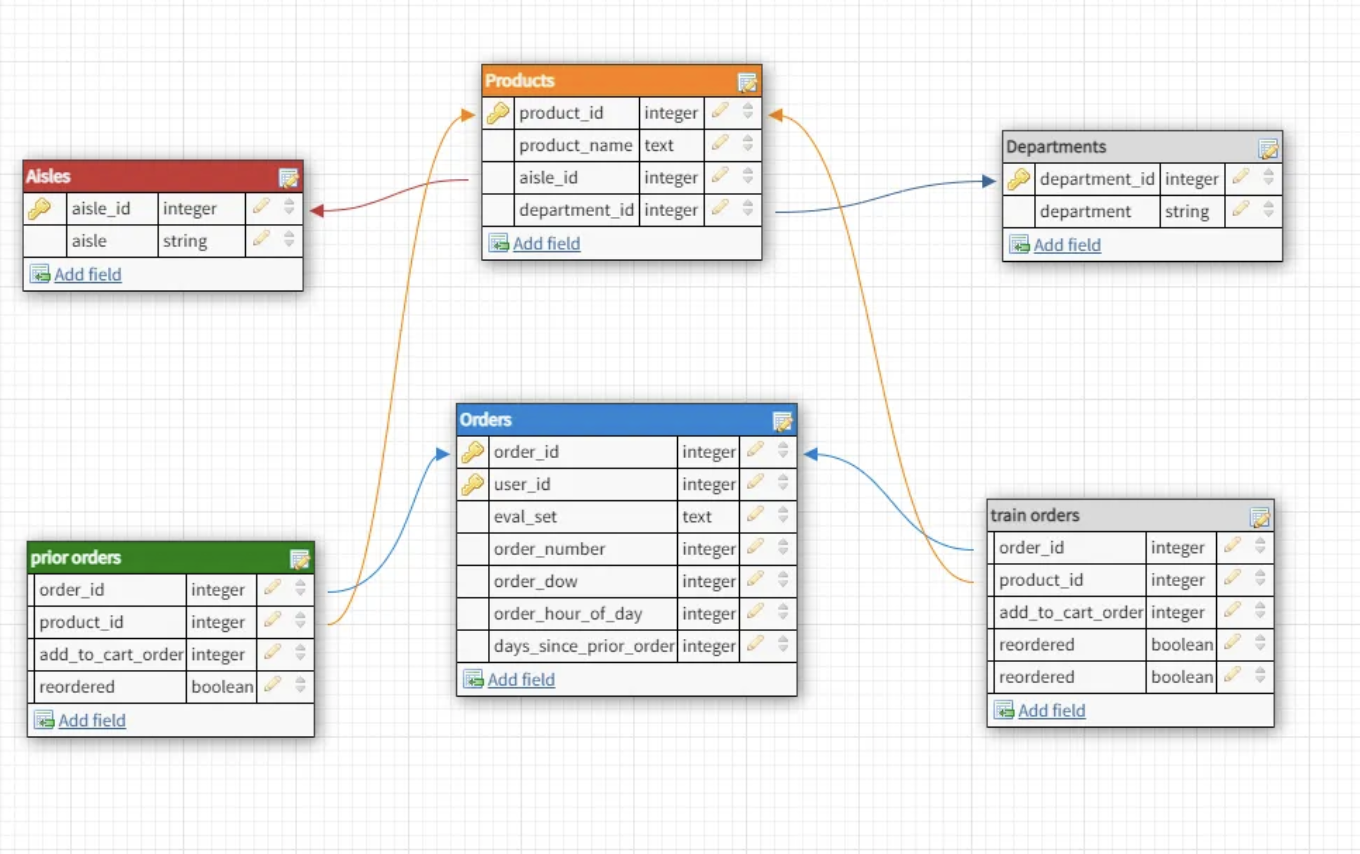

In [10]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [11]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [13]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [14]:
print('No. of unique values per column')
print('-------------------------------')
orders.nunique()

No. of unique values per column
-------------------------------


order_id                  3421083
user_id                    206209
eval_set                        3
order_number                  100
order_dow                       7
order_hour_of_day              24
days_since_prior_order         31
dtype: int64

In [15]:
orders.eval_set.unique()

array(['prior', 'train', 'test'], dtype=object)

In [16]:
print('Number of orders belonging to each set:')
orders.value_counts('eval_set')

Number of orders belonging to each set:


eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

*eval_set*: which evaluation set this order belongs in (train / test / prior)

*   prior: orders prior to that user's most recent order (3.2m orders)
*   train: user's most recent order for training (~131k orders)
*   test: user's most recent order test data for which we have to do prediction (75k orders)





In [17]:
orders.isna().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

These are not missing values. There are no prior order for the first order places by the user. Hence, this column's value for such cases are kept NaN.

In [18]:
order_products_prior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


order_products_prior contains all the products purchased in each prior order with the sequence of products purchased in that order. For both train and test users.

add_to_cart_order: order in which each product was added to cart.

reordered: 1 if this product has been ordered by the user in the past, 0 otherwise.

*   1 - 'reorder'
*   0 - 'first purchase'

In [19]:
order_products_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB


order_products_train contains all the products purchased in each train order with the sequence of products purchased in that order.

add_to_cart_order: order in which each product was added to cart.

reordered: 1 if this product has been ordered by the user in the past, 0 otherwise.

*   1 - 'reorder'
*   0 - 'first purchase'

# Data Cleaning

### Missing values

In [20]:
#aisles.isna().any()
#departments.isna().any()
#order_products_prior.isna().any()
#order_products_train.isna().any()
orders.isna().any()
#products.isna().any()

order_id                  False
user_id                   False
eval_set                  False
order_number              False
order_dow                 False
order_hour_of_day         False
days_since_prior_order     True
dtype: bool

### Data Duplication

In [21]:
#aisles.duplicated().any()
#departments.duplicated().any()
order_products_prior.duplicated().any()
#order_products_train.duplicated().any()
#orders.duplicated().any()
#products.duplicated().any()

False

### Garbage values

##### aisles

In [22]:
print('aisle_id', aisles.aisle_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('aisle', aisles.aisle.str.contains('[^a-zA-Z ]').any(), sep=' --> ')

aisle_id --> False
aisle --> False


##### departments

In [23]:
print('department_id', departments.department_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('department', departments.department.str.contains('[^a-zA-Z ]').any(), sep=' --> ')

department_id --> False
department --> False


##### products

In [24]:
print('product_id', products.product_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('aisle_id', products.aisle_id.astype('str').str.contains('[^0-9 ]').any(), sep=' --> ')
print('department_id', products.department_id.astype('str').str.contains('[^0-9 ]').any(), sep=' --> ')
print('product_name', products.product_name.astype('str').str.contains('[^a-zA-Z ]').any(), sep=' --> ')

product_id --> False
aisle_id --> False
department_id --> False
product_name --> True


In [25]:
import re
print('Special characters in product_name')
special_char = set(re.findall("[^a-zA-Z0-9 ]",''.join(products.loc[:,'product_name'])))
print(special_char)
print(f'Total {len(special_char)} distinct special characters.')

Special characters in product_name
{'™', '\x8f', 'é', ';', '’', 'á', '-', '"', ',', '®', '(', '@', '%', '$', 'ç', 'ñ', '{', "'", '+', '‑', '}', ')', '”', '\\', '!', ':', '#', '*', '/', '?', 'í', 'ó', '.', '°', 'û', '&', '\xa0', 'ô', 'â', 'ú', 'ü', '´', '=', '`', '–', 'è', '�', 'е', '˚'}
Total 49 distinct special characters.


In [26]:
for char in special_char:
  print(repr(char), products.loc[products.product_name.str.contains(char, regex=False), 'product_name'].iloc[0], sep = ' -- ')

'™' -- Mouthwash Clean Mint Listerine® Zero™
'\x8f' -- Hershey's Chocolate Creme Pie Singles
'é' -- Brut Rosé
';' -- Reg; Organic Apple Cider Vinegar 16 Fl Oz
'’' -- Kickin’ BBQ Chopped Salad
'á' -- Reserve Dark Roast Guatemala San Sebastián Ground Coffee
'-' -- All-Seasons Salt
'"' -- Easy Grab 9\"x13\" Oblong Glass Bakeware
',' -- Three Cheese Ziti, Marinara with Meatballs
'®' -- Tri-Vi-Sol® Vitamins A-C-and D Supplement Drops for Infants
'(' -- Fabric Refresher Meadows & Rain Air Freshener (1 Count, 27 oz)  Air Care
'@' -- Usual Suspects Variety Ales @ Lagers
'%' -- All Natural 100% Apple Juice
'$' -- Mini Apple Pie Pre Priced $3.99
'ç' -- Gluten Free Raw Green Superfood Goji & Açai Berry Drink Powder
'ñ' -- Hawaiian Sweet Jalepeño Rolls
'{' -- Fresh Effects {Everything Off!} Deluxe Make-Up Removal Wet Cloths
"'" -- Cut Russet Potatoes Steam N' Mash
'+' -- Totz Toothbrush Extra Soft 18+ Months
'‑' -- Pull-Ups Night‑Time Training Pants 2T‑3T
'}' -- Fresh Effects {Everything Off!} De

##### Removal of special characters and whitespaces from product_name

In [27]:
x = products.product_name.astype(str)\
                    .replace({'\xa0': '',
                               '\x8f': '',
                               r'[{}]': '',
                               r'\*': '',
                               r'e': 'ea',
                               '�': '',
                               '[-–‑]': ' ',
                               r';': '',
                               '=': ' equal to ',
                               '@': 'at',
                               '\+': ' plus ',
                               '[âá]': 'a',
                               '[еéè]': 'e',
                               'í': 'i',
                               'ñ': 'n',
                               '[óô]': 'o',
                               '[üûú]': 'u',
                               'ç': 'c',
                               '[°˚]': ' degree ',
                               '[®™]': '',
                               r"'s": '',
                               r'`s': '',
                               r'´s': '',
                               r"'": '',
                               r"’": '',
                               r"”": ' inch ',
                               r'\"': ' inch ',
                               r'\\': '',
                               ':': '',
                               '\?': ' ',
                               r',': '',
                               r'%': ' percent ',
                               r'&#':' No. ',
                               r'#': ' No. ',
                               r' & ': ' and ',
                               r'&': ' and ',
                               r'!': '',
                               r'24/7': ' 24_7 ',
                               r'w/': ' with ',
                               r'/': ' ',
                               r'\$': ' Dollar ',
                               'Bananas': 'Banana',
                               'Strawberries': 'Strawberry',
                               r'( )+': ' '},
                              regex = True)
x = x.str.strip()

In [28]:
products['product_name'] = x
del x
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49683,49684,Vodka Triple Distilled Twist of Vanilla,124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


##### orders

In [29]:
print('order_id', orders.order_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('user_id', orders.user_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('eval_set', orders.eval_set.astype('str').str.contains('[^\b(prior|train|test)\b]').any(), sep=' --> ')
print('order_number', orders.order_number.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('order_dow', not(orders.order_dow.between(0, 6).any()), sep=' --> ')
print('order_hour_of_day', not(orders.order_hour_of_day.between(0, 23).any()), sep=' --> ')
print('days_since_prior_order', not(orders.days_since_prior_order.between(0,30).any()),sep=' --> ')

order_id --> False
user_id --> False
eval_set --> False
order_number --> False
order_dow --> False
order_hour_of_day --> False
days_since_prior_order --> False


##### order_products_prior

In [30]:
print('order_id', order_products_prior.order_id.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('product_id', order_products_prior.product_id.astype('str').str.contains('[^0-9]').any(),sep= ' --> ')
print('add_to_cart_order', order_products_prior.add_to_cart_order.astype('str').str.contains('[^0-9]').any(), sep=' --> ')
print('reordered', not(order_products_prior.reordered.astype('uint8').between(0,1).any()),sep=' --> ')

order_id --> False
product_id --> False
add_to_cart_order --> False
reordered --> False


##### order_products_train

In [31]:
print('order_id', order_products_train.order_id.astype('str').str.contains('[^0-9]').any(),sep=' --> ')
print('product_id', order_products_train.product_id.astype('str').str.contains('[^0-9]').any(),sep=' --> ')
print('add_to_cart_order', order_products_train.add_to_cart_order.astype('str').str.contains('[^0-9]').any(),sep=' --> ')
print('reordered', not(order_products_train.reordered.astype('uint8').between(0,1).any()),sep=' --> ')

order_id --> False
product_id --> False
add_to_cart_order --> False
reordered --> False


In [32]:
prior_order = orders.merge(order_products_prior, how='inner', on='order_id')
prior_order.sort_values(['user_id', 'order_number', 'add_to_cart_order'], inplace=True, axis='index', ignore_index=True)
prior_order

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0
...,...,...,...,...,...,...,...,...,...,...
32434484,2977660,206209,prior,13,1,12,7.0,14197,5,1
32434485,2977660,206209,prior,13,1,12,7.0,38730,6,0
32434486,2977660,206209,prior,13,1,12,7.0,31477,7,0
32434487,2977660,206209,prior,13,1,12,7.0,6567,8,0


In [33]:
order_products = pd.concat([order_products_prior, order_products_train], ignore_index=True)
data = orders.merge(order_products, on='order_id')
data.sort_values(['user_id', 'order_number', 'add_to_cart_order'], inplace=True, axis='index', ignore_index=True)
data

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0
...,...,...,...,...,...,...,...,...,...,...
33819101,272231,206209,train,14,6,14,30.0,40603,4,0
33819102,272231,206209,train,14,6,14,30.0,15655,5,0
33819103,272231,206209,train,14,6,14,30.0,42606,6,0
33819104,272231,206209,train,14,6,14,30.0,37966,7,0


In [34]:
products_info = products.merge(departments,on='department_id').merge(aisles,on='aisle_id')
products_info

,product_id,product_name,aisle_id,department_id,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes
1,78,Nutter Butter Cookie Bites Go Pak,61,19,snacks,cookies cakes
2,102,Danish Butter Cookies,61,19,snacks,cookies cakes
3,172,Gluten Free All Natural Chocolate Chip Cookies,61,19,snacks,cookies cakes
4,285,Mini Nilla Wafers Munch Pack,61,19,snacks,cookies cakes
...,...,...,...,...,...,...
49683,22827,Organic Black Mission Figs,18,10,bulk,bulk dried fruits vegetables
49684,28655,Crystallized Ginger Chunks,18,10,bulk,bulk dried fruits vegetables
49685,30365,Vegetable Chips,18,10,bulk,bulk dried fruits vegetables
49686,38007,Naturally Sweet Plantain Chips,18,10,bulk,bulk dried fruits vegetables


In [35]:
departments_info = products_info.merge(order_products, on='product_id')
departments_info.head(3)

,product_id,product_name,aisle_id,department_id,department,aisle,order_id,add_to_cart_order,reordered
0,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes,1107,7,0
1,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes,5319,3,1
2,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes,7540,4,1


### EDA

##### Number of users in each set (train / test)

Text(0, 0.5, 'No. of users')

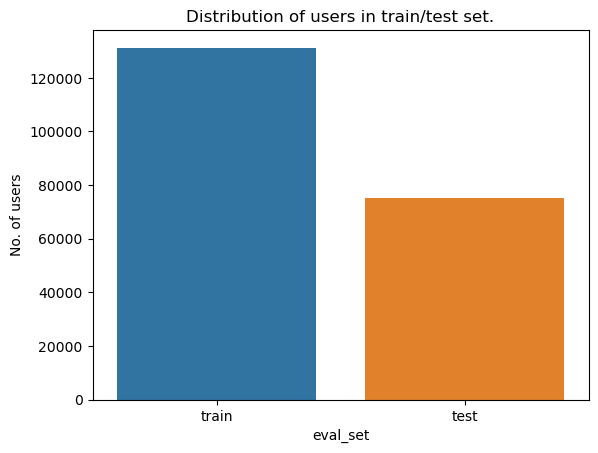

In [36]:
sns.countplot(x='eval_set',data=orders.loc[~orders.eval_set.str.contains('prior'),:])
plt.title('Distribution of users in train/test set.')
plt.ylabel('No. of users')

##### How many purchases are first order and reorder?

Text(0.5, 1.0, 'Purchases')

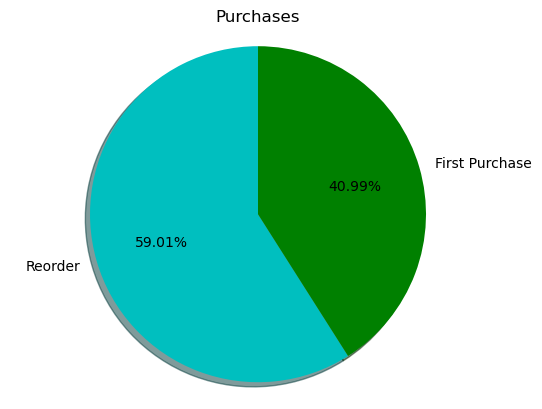

In [37]:
labels = ['Reorder', 'First Purchase']

purchase_percent = order_products['reordered'].value_counts(normalize=True) * 100
plt.pie(purchase_percent, labels = labels, colors = ['c', 'g'], startangle = 90, shadow = True, autopct = '%1.2f%%')
plt.axis('equal')
plt.title('Purchases')

##### Number of orders in each set

Text(0, 0.5, 'No. of orders')

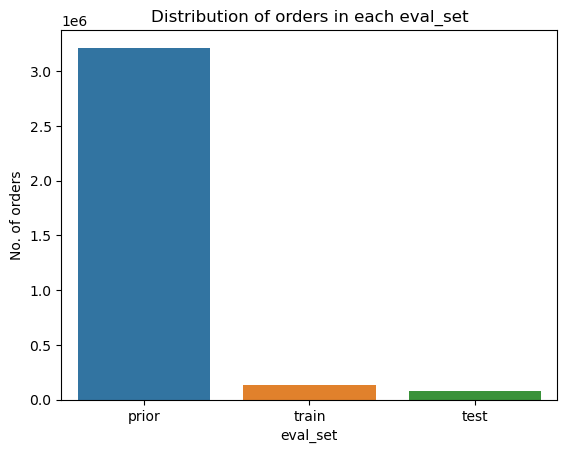

In [38]:
sns.countplot(x = 'eval_set', data = orders)
plt.title('Distribution of orders in each eval_set')
plt.ylabel('No. of orders')

##### Distribution of products per department

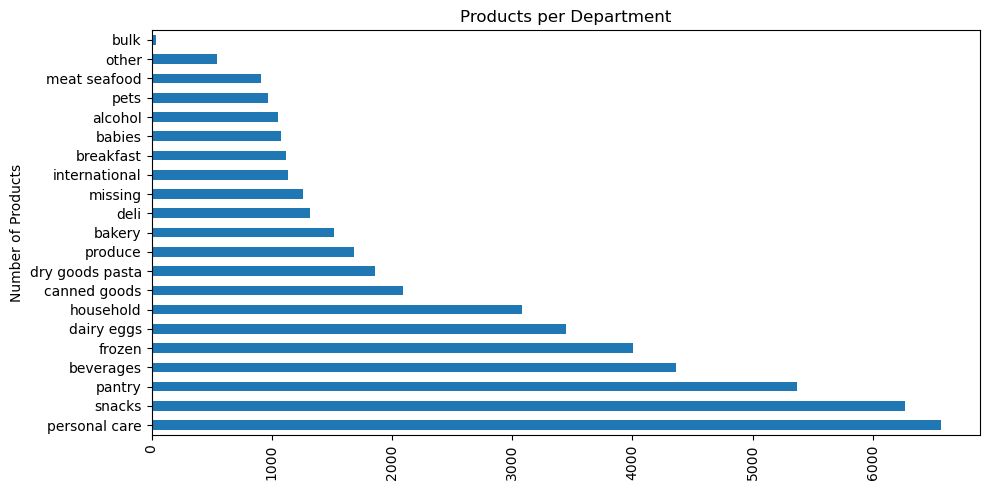

In [39]:
dept_counts = products_info['department'].value_counts().sort_values(ascending = False)
plt.figure(figsize = (10, 5))
dept_counts.plot(kind = 'barh')
plt.ylabel('Number of Products')
plt.title('Products per Department')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

Aisles by product count

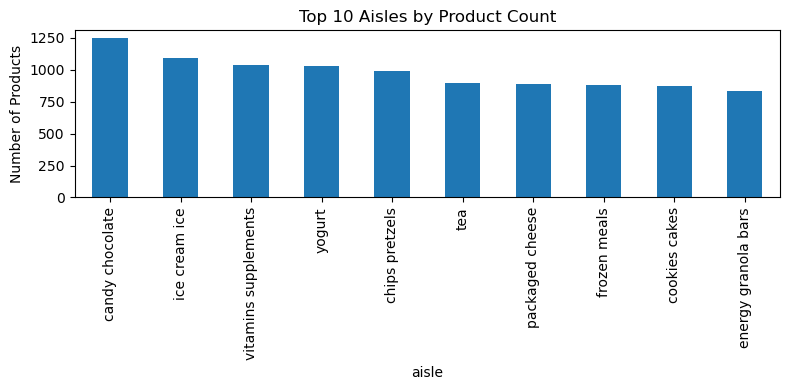

In [40]:
aisle_counts = products_info['aisle'].value_counts().iloc[1:11]
plt.figure(figsize=(8,4))
aisle_counts.plot(kind='bar')
plt.ylabel('Number of Products')
plt.title('Top 10 Aisles by Product Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

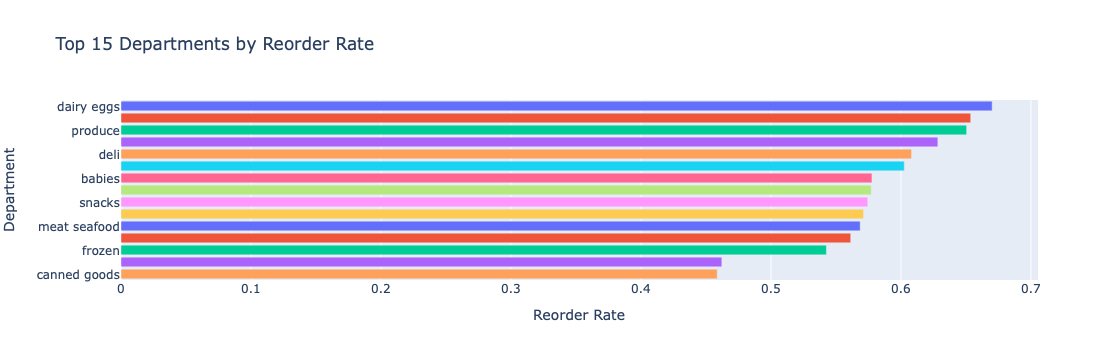

In [41]:
dept_reorder = (
    departments_info
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='reorder_rate')
)

fig = px.bar(
    dept_reorder,
    x='reorder_rate',
    y='department',
    orientation='h',
    color='department',
    title='Top 15 Departments by Reorder Rate',
    labels={'reorder_rate':'Reorder Rate', 'department':'Department'}
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    showlegend=False
)

fig.show()

In [42]:
order_info = (
    order_products
    .groupby('order_id')['reordered']
    .agg(
        reorder_count='sum',
        total_items='count',
        reorder_rate='mean'
    )
    .reset_index()
)

order_info.head()

,order_id,reorder_count,total_items,reorder_rate
0,1,4,8,0.500000
1,2,6,9,0.666667
2,3,8,8,1.000000
3,4,12,13,0.923077
4,5,21,26,0.807692


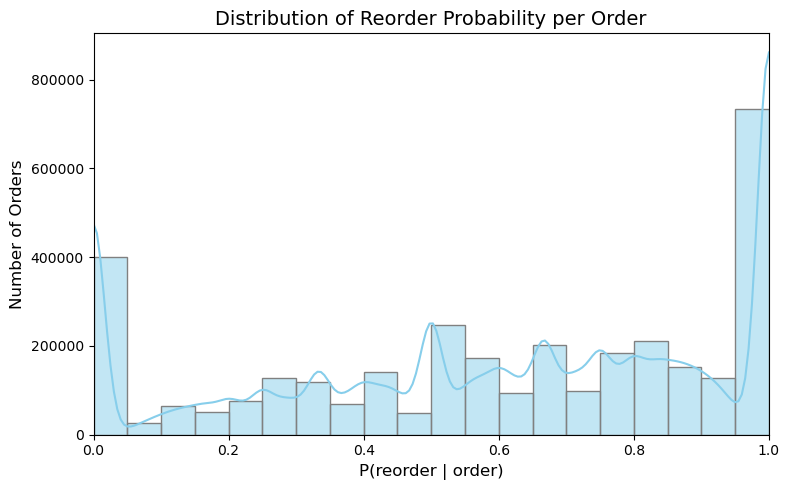

In [43]:
plt.figure(figsize = (8, 5))
sns.histplot(order_info, x = 'reorder_rate', bins = 20, kde = True, color = 'skyblue', edgecolor = 'gray')
plt.xlabel('P(reorder | order)', fontsize = 12)
plt.ylabel('Number of Orders', fontsize = 12)
plt.title('Distribution of Reorder Probability per Order', fontsize = 14)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

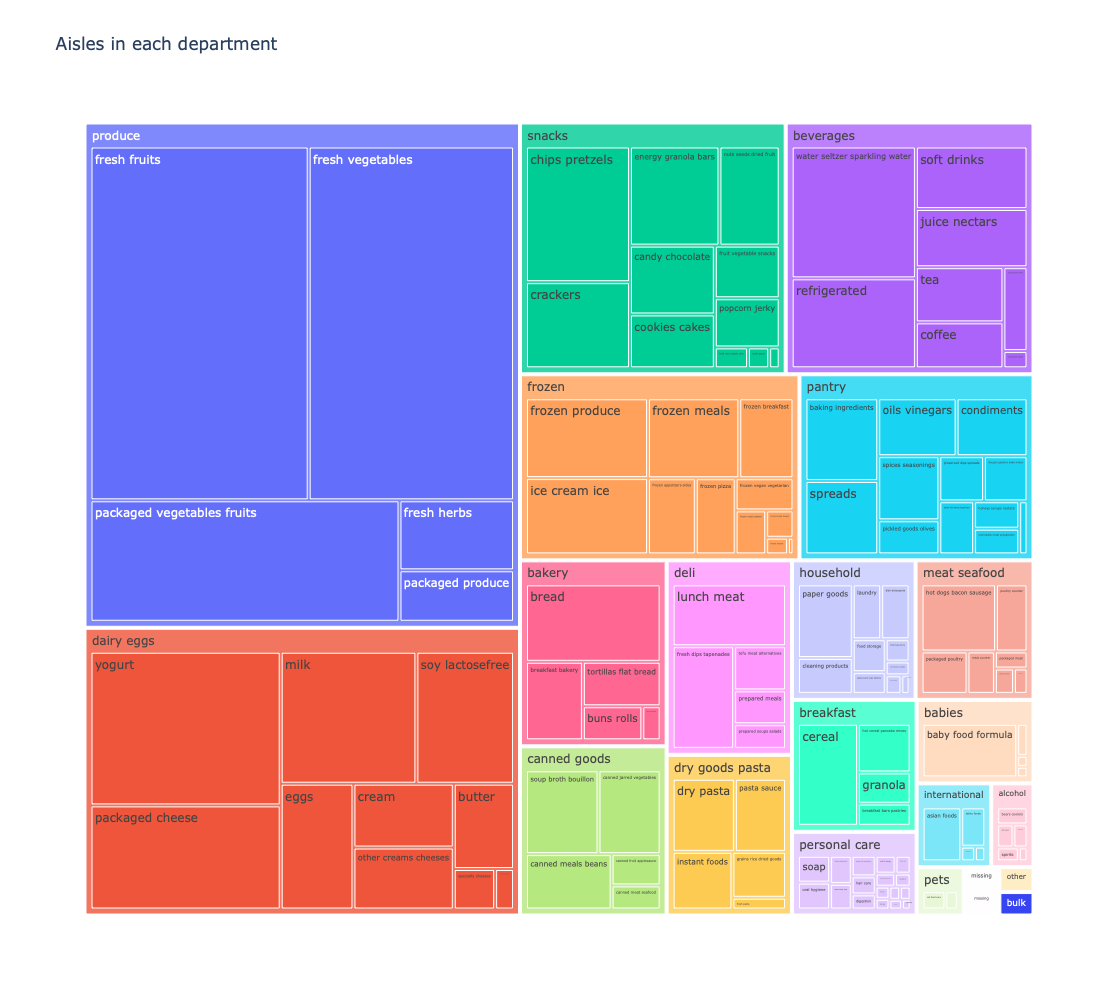

In [44]:
fig = px.treemap(departments_info, path = ['department', 'aisle'], title = 'Aisles in each department')
fig.update_layout(autosize = False, width = 1050, height = 1000)
fig.show()

In [45]:
departments_info['department'].unique()

array(['snacks', 'pantry', 'beverages', 'frozen', 'personal care',
       'dairy eggs', 'household', 'babies', 'meat seafood',
       'dry goods pasta', 'pets', 'breakfast', 'canned goods', 'produce',
       'missing', 'international', 'deli', 'alcohol', 'bakery', 'other',
       'bulk'], dtype=object)

In [46]:
department_eatables = {'snacks', 'pantry', 'beverages', 'frozen', 'dairy eggs', 'meat seafood', 'dry goods pasta', 'breakfast', 'canned goods', 'produce', 'international', 'deli', 'alcohol', 'bakery', 'bulk'}
unique_pairs = departments_info.loc[departments_info['department'].isin(department_eatables), ['department', 'aisle']].drop_duplicates()
print('Number of aisles with eatable items: ', unique_pairs.shape[0])

Number of aisles with eatable items:  99


##### Average Number of Reorders Per Department

avg_reorders = ∑ (No. of reorders from the department) / No. of distinct products in department

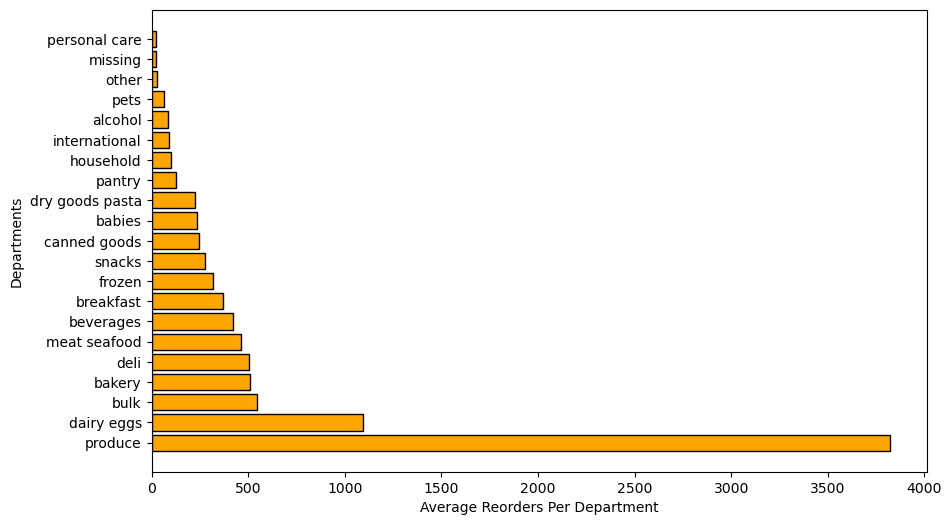

In [47]:
dept_stats = departments_info.groupby('department').agg(total_reorders = ('reordered', 'sum'), distinct_products = ('product_id', 'nunique')
                                                        ).assign(avg_reorders_per_product = lambda d: d['total_reorders'] / d['distinct_products']).reset_index()
# dept_stats.head()

dept_stats['avg_reorders_per_product'] = dept_stats['avg_reorders_per_product'].apply(lambda x: round(x, 2))
dept_stats = dept_stats.sort_values('avg_reorders_per_product', ascending = False)

plt.figure(figsize = (10, 6))
plt.barh(dept_stats['department'], dept_stats['avg_reorders_per_product'], color = 'orange', edgecolor = 'black')
plt.xlabel('Average Reorders Per Department')
plt.ylabel('Departments')
plt.show()

##### Probability of reorder from each department

P(reorder | department) = # of reorders from the department / # of purchases from the department

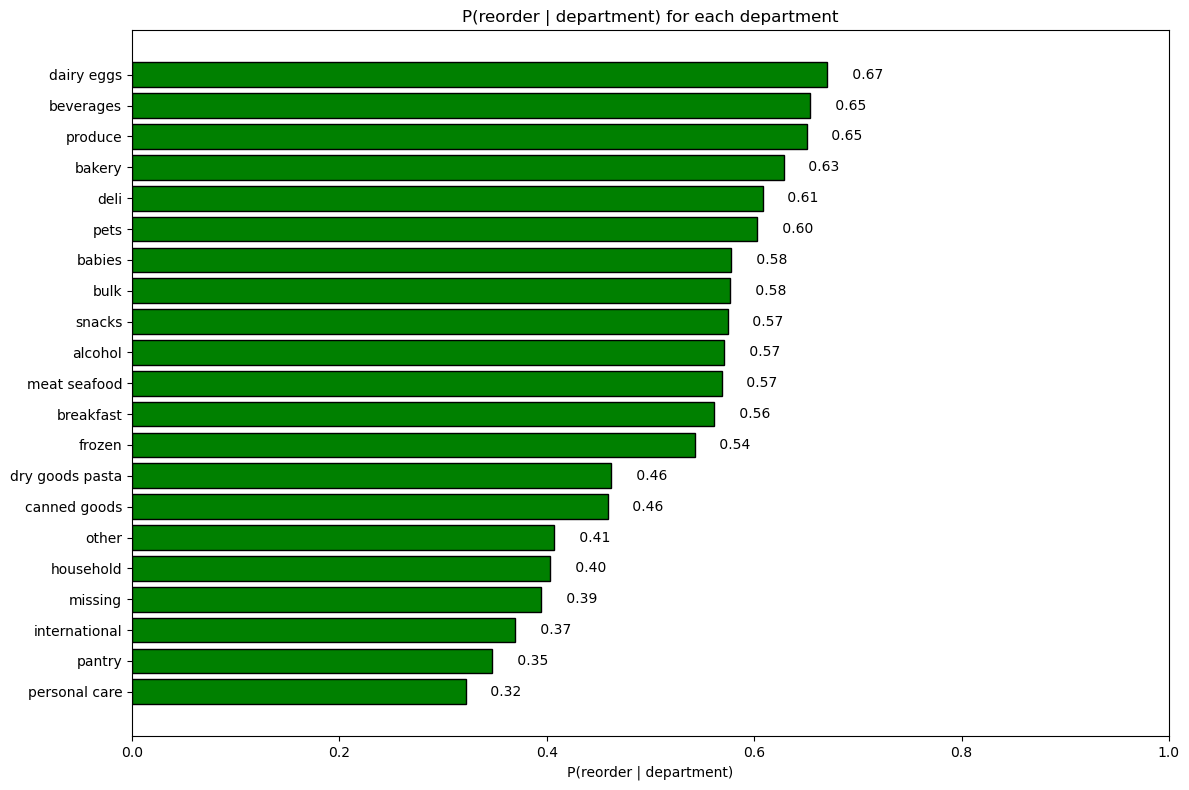

In [48]:
dept_probs = departments_info.groupby('department')['reordered'].mean().sort_values(ascending = False)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(dept_probs.index, dept_probs.values, color = 'green', edgecolor = 'black')
ax.invert_yaxis()
ax.set_xlabel('P(reorder | department)')
ax.set_title('P(reorder | department) for each department')
ax.set_xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(width + 0.02, y_pos, f'{width: .2f}', va = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

##### Probability of reorder from each aisle

P(reorder | aisle) = # of reorders from the aisle / # of purchases from the aisle

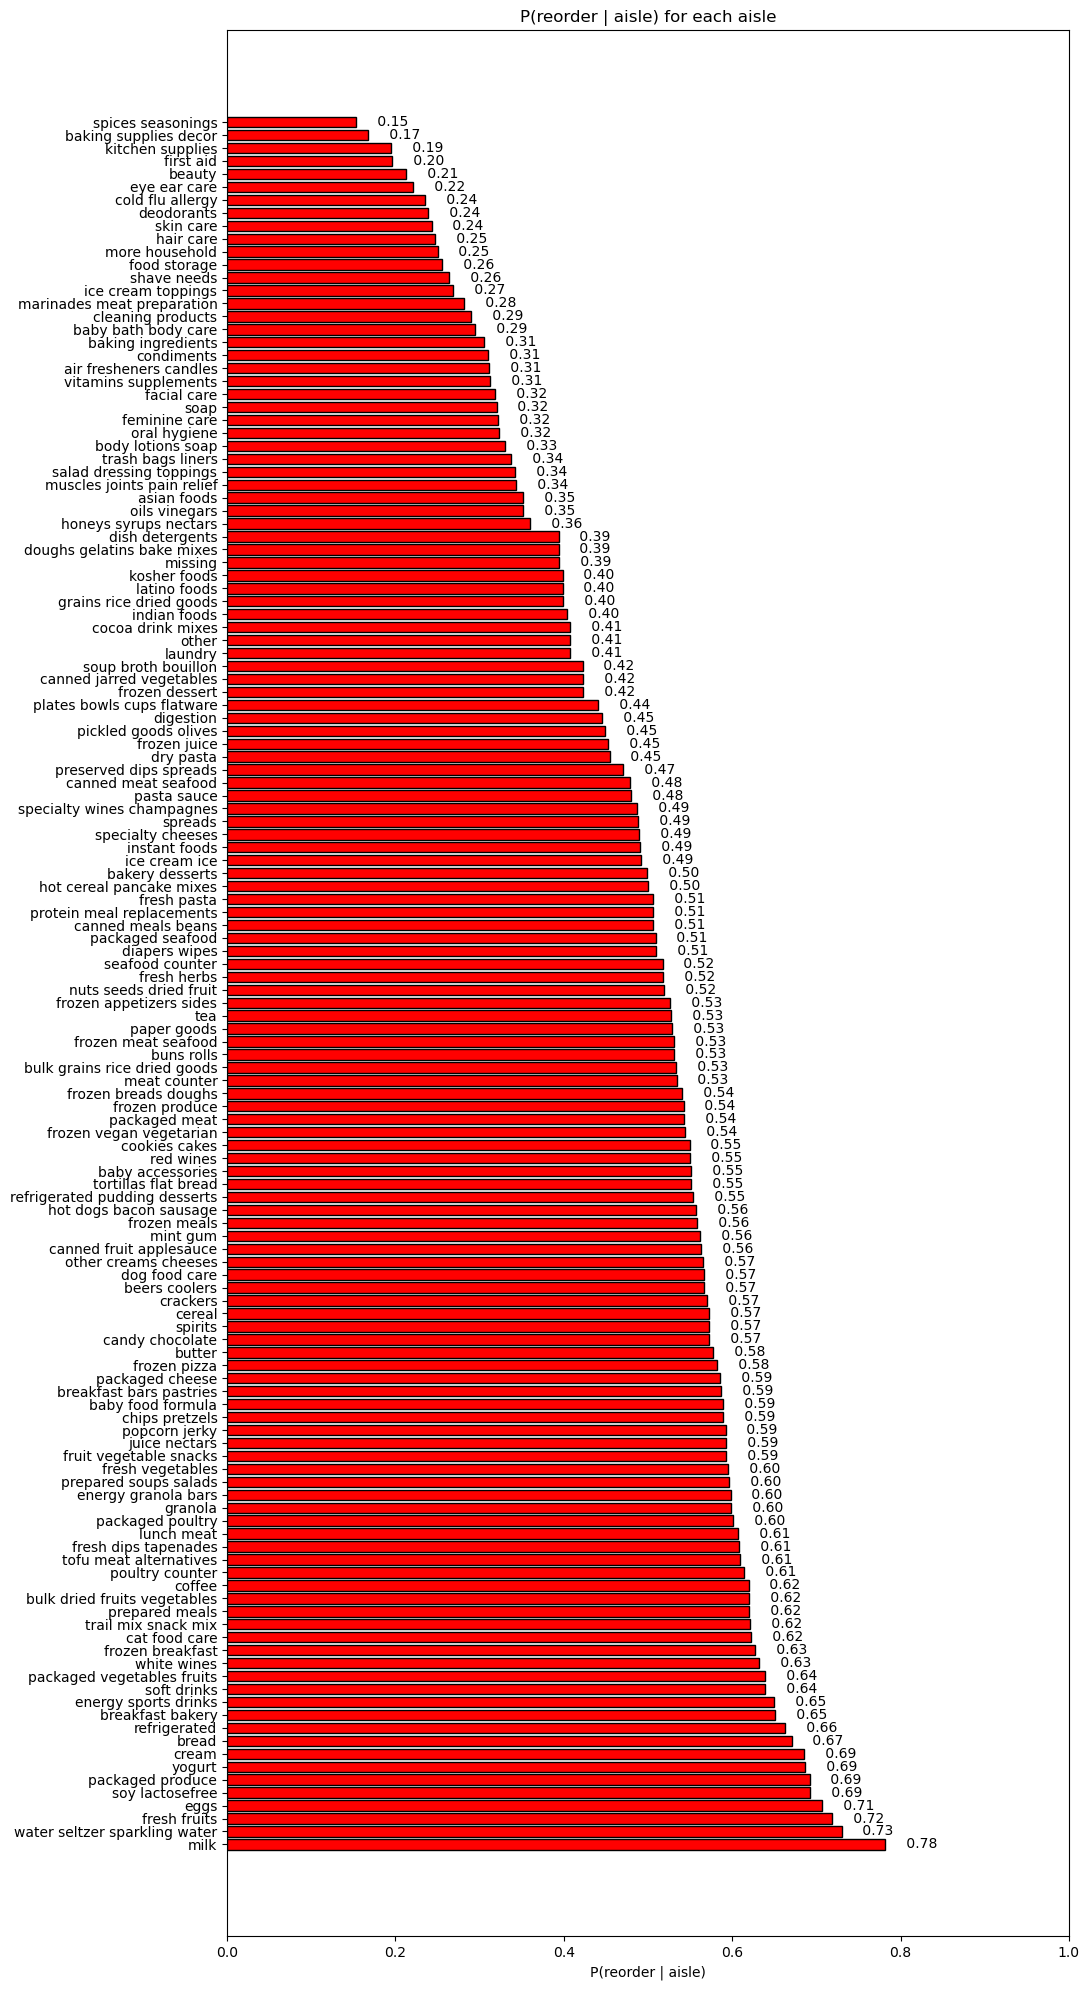

In [49]:
aisle_probs = order_products.merge(products_info, on = 'product_id').groupby('aisle')['reordered'].mean().sort_values(ascending = True)
fig, ax = plt.subplots(figsize=(11, 20))
bars = ax.barh(aisle_probs.index, aisle_probs.values, color = 'red', edgecolor = 'black')
ax.invert_yaxis()
ax.set_xlabel('P(reorder | aisle)')
ax.set_title('P(reorder | aisle) for each aisle')
ax.set_xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(width + 0.02, y_pos, f'{width: .2f}', va = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

##### Number of products sold after a gap of certain number of days in customer's order

Text(0.5, 1.0, 'Gap between products sold in prior order and current')

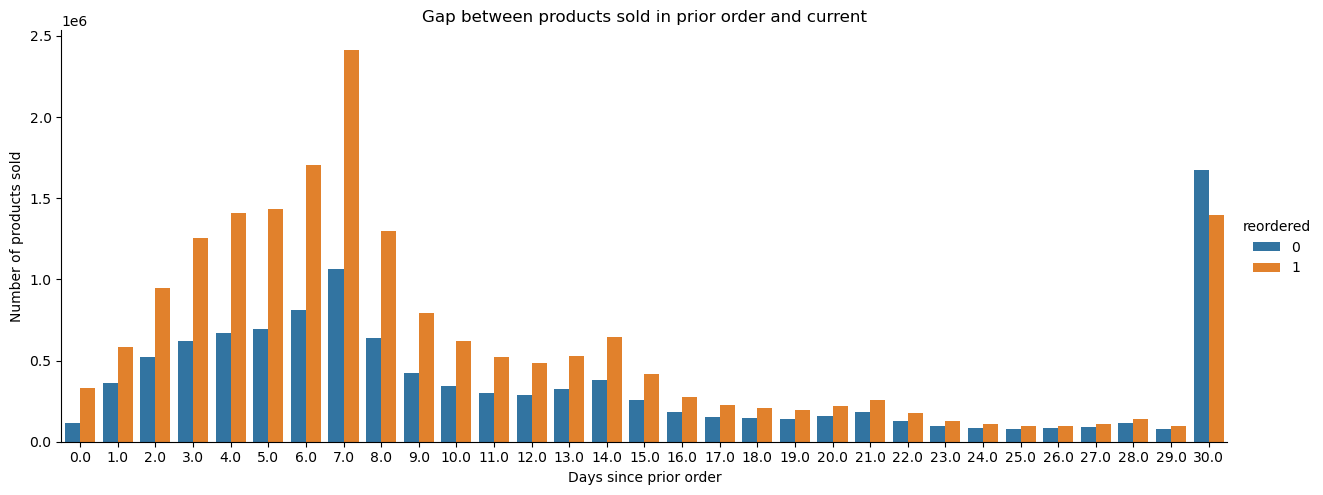

In [50]:
sns.catplot(x = 'days_since_prior_order', hue= 'reordered' , data = prior_order, kind = 'count', aspect=2.5)
plt.ylabel('Number of products sold')
plt.xlabel('Days since prior order')
plt.title("Gap between products sold in prior order and current")

##### Find out which product was ordered the most?

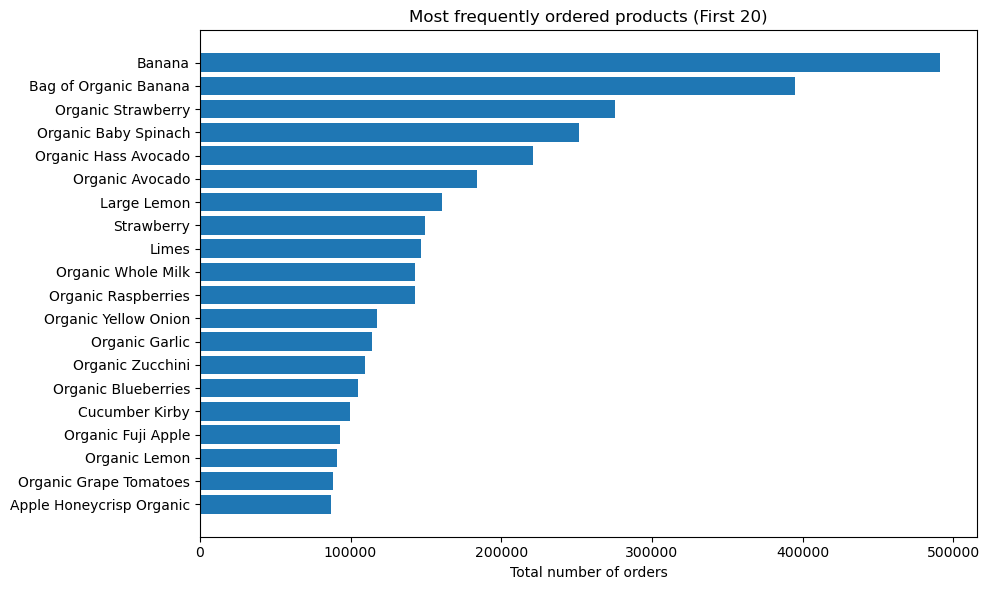

In [51]:
prod_counts = order_products['product_id'].value_counts().reset_index()
prod_counts.columns = ['product_id', 'order_count']
prod_counts = prod_counts.merge(products[['product_id', 'product_name']], on = 'product_id', how = 'left')
first_20 = prod_counts.nlargest(20, 'order_count').sort_values('order_count', ascending = True)

plt.figure(figsize = (10, 6))
plt.barh(first_20['product_name'], first_20['order_count'])
plt.xlabel('Total number of orders')
plt.title('Most frequently ordered products (First 20)')
plt.tight_layout()
plt.show()

##### How many products have number of add_to_cart_order placed in an order?

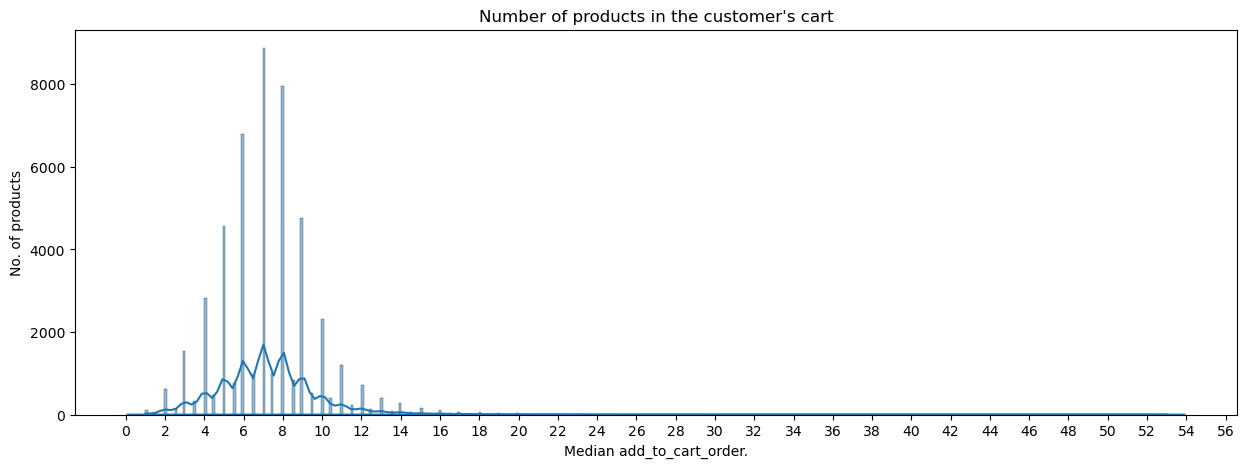

In [52]:
fig, ax = plt.subplots(figsize = (15, 5))
sns.histplot(order_products.groupby('product_id')['add_to_cart_order'].median(), kde = True, ax = ax)
sns.kdeplot(order_products.groupby('product_id')['add_to_cart_order'].median(),ax = ax)
plt.ylabel('No. of products')
plt.xlabel('Median add_to_cart_order.')
plt.title("Number of products in the customer's cart")
plt.xticks(np.arange(0,58,2));

### Feature Engineering

- Number of times the user reordered and purchased the order

In [53]:
user_activity = prior_order.groupby('user_id')['reordered'].agg(['sum', 'count']).rename(columns = {'sum': 'user_reorders', 'count': 'user_purchases'}).reset_index()
user_activity.head()

,user_id,user_reorders,user_purchases
0,1,41,59
1,2,93,195
2,3,55,88
3,4,1,18
4,5,14,37


- Probability the user reorders when begin purchasing

In [54]:
user_activity['P(reorder | user)'] = user_activity['user_reorders'] / user_activity['user_purchases']
user_activity.head()

,user_id,user_reorders,user_purchases,P(reorder | user)
0,1,41,59,0.694915
1,2,93,195,0.476923
2,3,55,88,0.625000
3,4,1,18,0.055556
4,5,14,37,0.378378


In [55]:
1 in prior_order['order_id'].unique()

False

In [56]:
user_activity_per_order = prior_order.groupby(['user_id', 'order_id'])['reordered'].agg(['sum', 'count']).rename(columns = {'sum': 'user_reorders', 'count': 'user_purchases'}).reset_index()
user_activity_per_order['P(reorder | user)'] = user_activity_per_order['user_reorders'] / user_activity_per_order['user_purchases']
user_activity_per_order[user_activity_per_order['user_id'] == 1]

,user_id,order_id,user_reorders,user_purchases,P(reorder | user)
0,1,431534,5,8,0.625000
1,1,473747,3,5,0.600000
2,1,550135,5,5,1.000000
3,1,2254736,5,5,1.000000
4,1,2295261,6,6,1.000000
5,1,2398795,3,6,0.500000
6,1,2539329,0,5,0.000000
7,1,2550362,6,9,0.666667
8,1,3108588,4,6,0.666667
9,1,3367565,4,4,1.000000


In [57]:
dep_info = departments_info.groupby('department_id', as_index = False).agg({'reordered': 'mean'}).rename(columns = {'reordered': 'reorder_dept_rate'})
dep_info.head(3)

,department_id,reorder_dept_rate
0,1,0.542634
1,2,0.407052
2,3,0.628381


In [58]:
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


### Hierarchical Logistic Regression

In [59]:
df = order_products_train.merge(orders[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day']], on = 'order_id').merge(products[['product_id', 'aisle_id', 'department_id']], on = 'product_id')

In [60]:
overall_rate = df['reordered'].mean()
overall_rate

0.5985944127509629

<Axes: xlabel='order_number'>

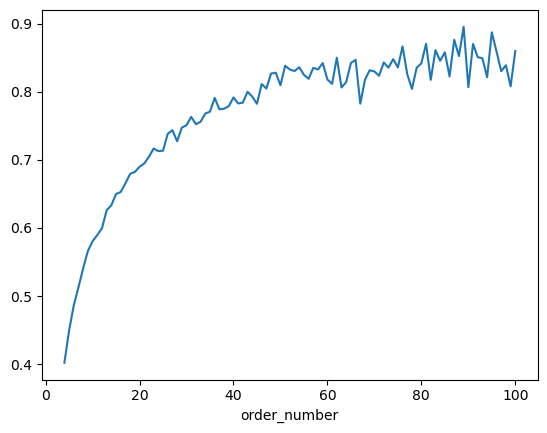

In [61]:
df.groupby('order_number')['reordered'].mean().plot()

In [62]:
df.groupby('order_dow')['reordered'].mean()

order_dow
0    0.609624
1    0.598977
2    0.588365
3    0.586724
4    0.594632
5    0.606178
6    0.594238
Name: reordered, dtype: float64

In [63]:
df.groupby('order_hour_of_day')['reordered'].mean()

order_hour_of_day
0     0.571177
1     0.579453
2     0.579665
3     0.581624
4     0.598108
5     0.622823
6     0.650629
7     0.649496
8     0.643353
9     0.623263
10    0.606378
11    0.594423
12    0.587193
13    0.589533
14    0.592201
15    0.583384
16    0.588795
17    0.592177
18    0.584747
19    0.590529
20    0.596921
21    0.607934
22    0.604195
23    0.589979
Name: reordered, dtype: float64

In [64]:
df.groupby('product_id')['reordered'].mean().describe()

count    39123.000000
mean         0.434919
std          0.316078
min          0.000000
25%          0.166667
50%          0.485714
75%          0.654556
max          1.000000
Name: reordered, dtype: float64

##### Compute cart size

In [65]:
cart_size = order_products_train.groupby('order_id').size().reset_index(name = 'cart_size')

In [66]:
cart_df = order_products_train.merge(orders[['order_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'user_id']], on = 'order_id', how = 'left').merge(cart_size, on = 'order_id', how = 'left').merge(products[['product_id', 'aisle_id', 'department_id']], on = 'product_id', how = 'left')

In [84]:
user_avg = cart_df.groupby('user_id')['cart_size'].mean().reset_index(name = 'avg_cart_size')

In [85]:
cart_df = cart_df.merge(user_avg, on = 'user_id', how = 'left')

In [67]:
# Features to evaluate
num_feats = ['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cart_size']
cat_feats = ['aisle_id', 'department_id']

In [68]:
# Pearson correlation for numeric features
numeric_corr = {
    feat: cart_df[feat].corr(cart_df[
        'reordered'])
    for feat in num_feats
}

numeric_corr_df = pd.DataFrame.from_dict(
    numeric_corr, orient = 'index', columns = ['corr_with_reordered']
).sort_values('corr_with_reordered', key = abs, ascending = False)

print(numeric_corr_df)

                        corr_with_reordered
order_number                       0.223947
days_since_prior_order            -0.160152
cart_size                          0.025111
order_hour_of_day                 -0.017840
order_dow                         -0.006714


In [69]:
# Signal Strength for categorical features
cat_signal = []
for feat in cat_feats:
    rates = df.groupby(feat)['reordered'].mean()
    cat_signal.append({
        'feature': feat,
        'num_categories': rates.size,
        'std_of_rates': rates.std(),
        'min_rate': rates.min(),
        'max_rate': rates.max()
    })

cat_signal_df = pd.DataFrame(cat_signal).set_index('feature')
print(cat_signal_df)

               num_categories  std_of_rates  min_rate  max_rate
feature                                                        
aisle_id                  134      0.139829  0.165320  0.792305
department_id              21      0.110764  0.337089  0.674966


In [70]:
df = df.sample(n = 5000, random_state = 42)
cart_df = cart_df.sample(n = 5000, random_state = 42)

In [71]:
# Integer Indices for random effects
model_l = df[['user_id', 'product_id', 'order_number', 'order_dow', 'order_hour_of_day', 'reordered']].copy()
model_l['user_idx'] = model_l['user_id'].astype('category').cat.codes
model_l['product_idx'] = model_l['product_id'].astype('category').cat.codes

### MATH BEHIND 'hierarchical logistic regression'
- un = User Index
- pn = Product Index
- xn,1 = order_num[n]: Order number
- xn,2 = ord_dow[n]: Day of week
- xn,3 = ord_hour[n]: Hour of Day
- yn = Indicator that this product was reordered.

Global Intercept α and random intercepts for users and products, plus fixed slopes for three predictors.

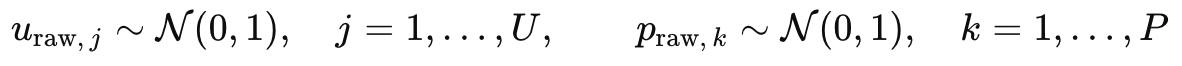
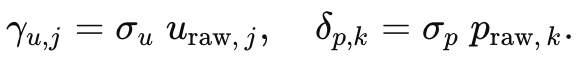

Priors

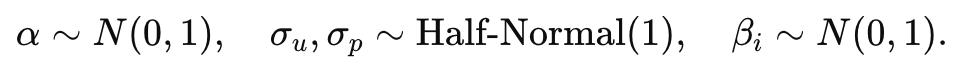

Transformed parameters

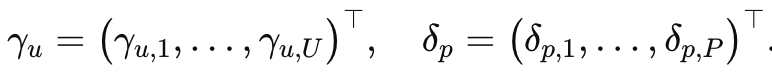

Linear predictor (log-odds)

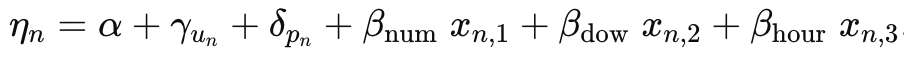
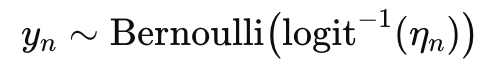

Posterior Inference

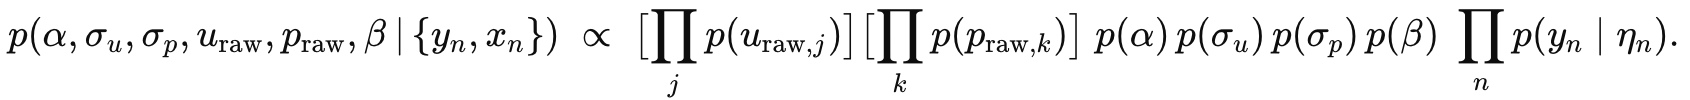


In [72]:
stan_data = {
    "N": len(model_l),
    "U": int(model_l.user_idx.max()) + 1,
    "P": int(model_l.product_idx.max()) + 1,
    # Stan uses 1-based indices:
    "user_idx": (model_l.user_idx.values + 1).astype(int),
    "prod_idx": (model_l.product_idx.values + 1).astype(int),
    "ord_num":  model_l.order_number.values,
    "ord_dow":  model_l.order_dow.values,
    "ord_hour": model_l.order_hour_of_day.values,
    "y":        model_l.reordered.values.astype(int),
}

In [75]:
from cmdstanpy import CmdStanModel, install_cmdstan
install_cmdstan()

model = CmdStanModel(stan_file='hier_logit.stan')

for name in ['ord_num', 'ord_dow', 'ord_hour']:
    arr = stan_data[name]
    stan_data[name] = (arr - np.mean(arr)) / np.std(arr)

fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    iter_warmup=1000,    
    iter_sampling=1000,   
    adapt_delta = 0.99,
    max_treedepth = 15
            
)

print(fit.diagnose())


CmdStan install directory: /Users/sailaxmankotha/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


18:20:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

18:28:58 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.16, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma_u, beta_num, gamma_u[88], gamma_u[965], gamma_u[974], gamma_u[1068], gamma_u[1152], gamma_u[1324], gamma_u[1472], gamma_u[1596], gamma_u[2560], gamma_u[3015], gamma_u[3234], gamma_u[4144], gamma_u[4276], gamma_u[4383], gamma_u[4386], gamma_u[4518], gamma_u[4776]
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizating your model with additional prior information or a more effective par

In [76]:
print(fit.summary())

                      Mean       MCSE      StdDev         MAD           5%  \
lp__          -6628.590000  27.014400  206.711000  192.679000 -6892.110000   
alpha             0.442964   0.005111    0.056586    0.051335     0.360823   
sigma_u           0.616723   0.055183    0.396851    0.422904     0.053541   
sigma_p           0.764783   0.009517    0.109025    0.101055     0.601931   
u_raw[1]         -0.263322   0.014606    0.955657    0.949165    -1.798120   
...                    ...        ...         ...         ...          ...   
delta_p[2862]    -0.158349   0.008681    0.708479    0.690776    -1.324920   
delta_p[2863]     0.310037   0.008632    0.688265    0.668677    -0.795897   
delta_p[2864]     0.179977   0.007741    0.699336    0.658334    -0.931251   
delta_p[2865]     0.186365   0.008838    0.719827    0.688563    -0.959787   
delta_p[2866]    -0.243854   0.007298    0.636290    0.628411    -1.280380   

                       50%          95%   ESS_bulk  ESS_tail   

- Mean - posterior mean for each parameter θ
- MCSE - Monte Carlo Standard Error: an estimate of the error in the monte carlo estimate of the mean
- StdDev - The posterior standard deviation √Var(θ)
- MAD - Median Absolute deviation
- 5%, 50%, 95% - Posterior quantiles
- ESS_bulk - Effective sample size for estimating means
- ESS_tail - Effective sample size of tail quantiles
- R_hat - Gelman_Rubin split-R statistic

- Ip__ => log-posterior density
- `alpha` => Mean = 0.44 => global intercept on log-odds scale. Baseline reorder probability of logistic(0.44) ≈ 0.61
- `sigma_u` and `sigma_p` => Group-level standard deviations for users and products

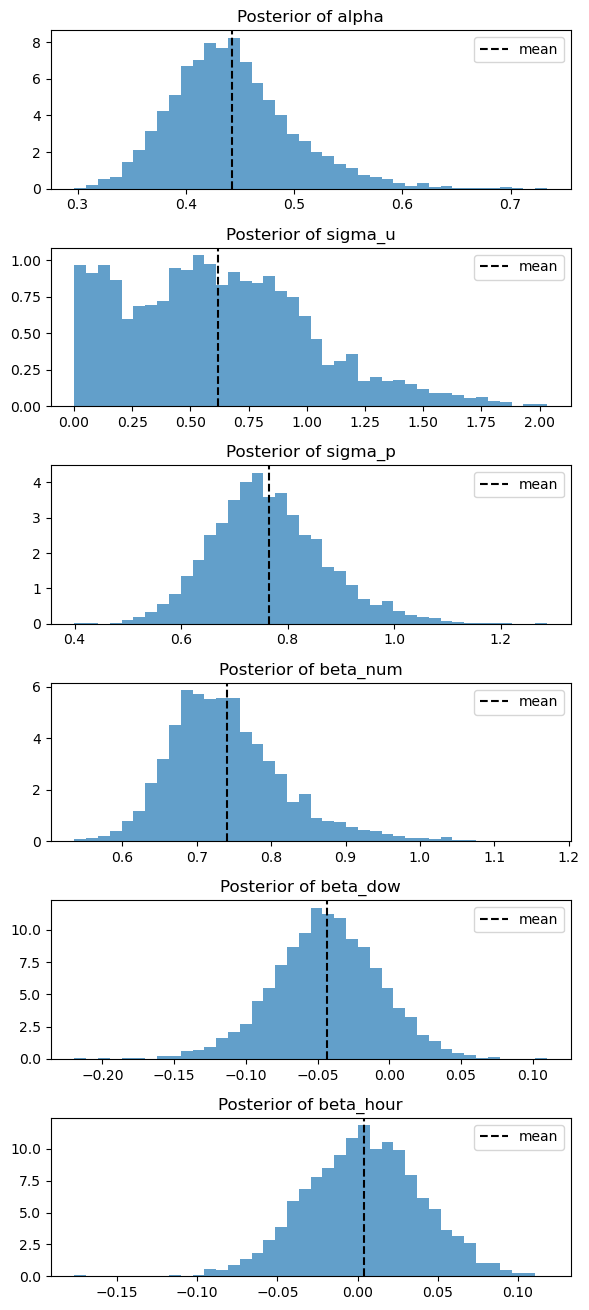

In [78]:
df = fit.draws_pd()

# posteriors of the hyper-parameters + fixed slopes
params = ['alpha','sigma_u','sigma_p','beta_num','beta_dow','beta_hour']
fig, axes = plt.subplots(len(params), 1, figsize=(6, len(params)*2.2))

for ax, name in zip(axes, params):
    ax.hist(df[name], bins=40, density=True, alpha=0.7)
    ax.set_title(f"Posterior of {name}")
    ax.axvline(df[name].mean(), color='k', linestyle='--', label='mean')
    ax.legend()

plt.tight_layout()
plt.show()

#### Alpha (Global Intercept)
##### Posterior of alpha:
- Peak around 0.44 means the baseline log-odds of a reorder (when all the predictors are at their mean and user / product effects are zero) is about 0.44
- p0 = logistic(0.44) ~ 0.61
  So an average user buying an average product has ~61% chance to reorder

#### sigma_p (Product-effect SD)
##### Posterior of sigma_p:
- Peaking aroud 0.75. That means products vary a bit more than users: 95% of a product offsets i.e odds ratios between [0.22, 4.5]

#### beta_num (Slope for ord_num)
##### Posterior of beta_num:
- Centered around ~0.75.
- One SD increase in 'order_number' has 0.75 to the log-odds of reorder. exp(0.75) =2.117. Higher order_num are about twice a likely to be reorders

#### beta_dow (Slope for ord_dow)
##### Posterior of beta_dow:
- Centered just below zero (~-0.05)
- A one-SD increase in day-of-week slightly decreases the log-odds of a reorder by 0.05. exp(-0.05) =0.951. That is 5% drop in odds

#### beta_hour (Slope for ord_hour)
##### Posterior of beta_hour:
- Mean very close to zero, and the density straddles zero.
- Hour of day has no strong effect on reorder probabilty.

The widths of the histograms tell how certain the model is about each parameter, 
narrower => more certain, tighter => predictive uncertainty.

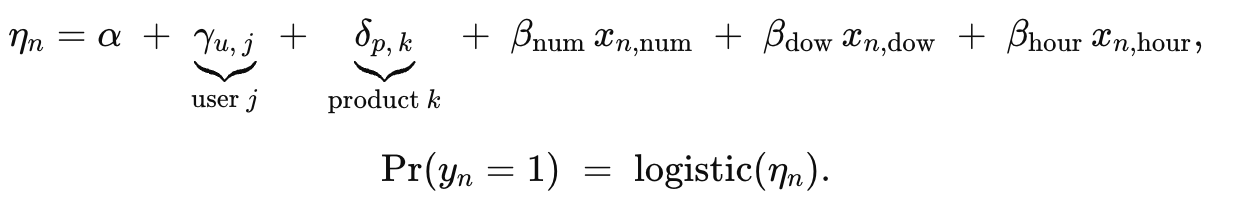

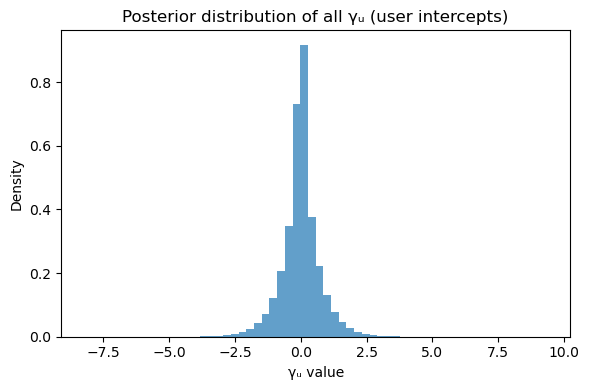

In [79]:
# Distribution of user‐random intercepts (all users pooled)
gamma_cols = [c for c in df.columns if c.startswith('gamma_u[')]
all_gamma = df[gamma_cols].values.flatten()

plt.figure(figsize=(6,4))
plt.hist(all_gamma, bins=60, density=True, alpha=0.7)
plt.title("Posterior distribution of all γᵤ (user intercepts)")
plt.xlabel("γᵤ value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Yu Value - the estimated user‐specific intercept on the log-odds scale.
- A ru,j of 0 means “that user is exactly average”—no shift from the global intercept alpha.
- A positive ru,j means that user is more likely to reorder (shifting log-odds up)
- A negative ru,j means that user is less likely (shifting log-odds down)

A tall spike near zero tells most users have intercepts very close to glbal mean. The flatter tails show that a handful of users get pulled out to higher positive or negative log-odds.

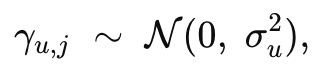

Note: Stan “shrinks” individual user intercepts toward zero—especially for users with few orders—while still allowing truly extreme cases (heavy tail)

For a new order n, the linear predictor is

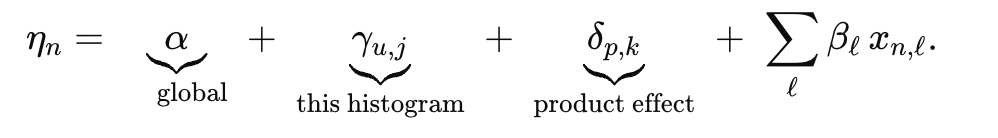

- draw a ru,j ~ +1, the user's log-odds by 1. Reorder rate by 2.7 times

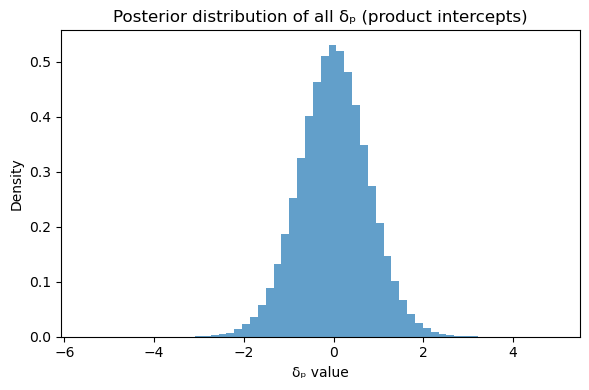

In [81]:
# Product Intercepts
delta_cols = [c for c in df.columns if c.startswith('delta_p[')]
all_delta = df[delta_cols].values.flatten()

plt.figure(figsize=(6,4))
plt.hist(all_delta, bins=60, density=True, alpha=0.7)
plt.title("Posterior distribution of all δₚ (product intercepts)")
plt.xlabel("δₚ value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Each delta(p,k) is the product-specific shift on the log-odds scale
- value of zero means that the product behaves exactly at the baseline.
- positive values mean that product is more likely to be reordered that average.
- negative values mean less likely

#### What's the probability user u will reorder product p on their nth order?
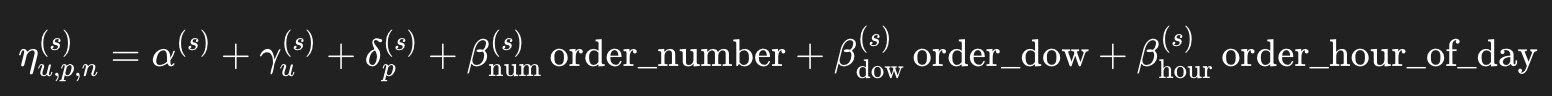
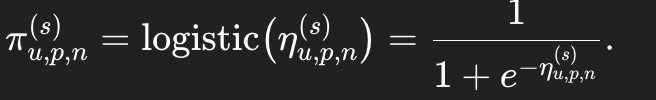

In [117]:
u    = 1235         # zero‐based user index
p    =  563         # zero‐based product index
num  =    5         # order_number
dow  =    2         # order_dow
hour =   15         # order_hour_of_day

# Extract posterior draws
alpha_draws   = fit.stan_variable('alpha')        
beta_num      = fit.stan_variable('beta_num')
beta_dow      = fit.stan_variable('beta_dow')
beta_hour     = fit.stan_variable('beta_hour')

# arrays of shape (n_draws, U) and (n_draws, P)
gamma_u_mat   = fit.stan_variable('gamma_u')     # shape (n_draws, U)
delta_p_mat   = fit.stan_variable('delta_p')     # shape (n_draws, P)

# Index into those matrices to get one vector per draw:
gamma_u_draws = gamma_u_mat[:, u]   # user’s intercept draws
delta_p_draws = delta_p_mat[:, p]   # product’s intercept draws

# log-odds η for each draw:
eta = (
    alpha_draws
  + gamma_u_draws
  + delta_p_draws
  + beta_num  * num
  + beta_dow  * dow
  + beta_hour * hour
)

# Transform to probability via the logistic function:
pi_draws = 1/(1 + np.exp(-eta))

# Summarize
pi_mean = pi_draws.mean()
pi_ci   = np.percentile(pi_draws, [2.5, 97.5])

print(f"Reorder probability for user={u}, product={p}:")
print(f"  Posterior mean = {pi_mean:.3f}")
print(f"  95% CI         = [{pi_ci[0]:.3f}, {pi_ci[1]:.3f}]")


Reorder probability for user=1235, product=563:
  Posterior mean = 0.977
  95% CI         = [0.899, 0.999]


### MATH BEHIND 'bayesian poisson regression'
- xi,1 = order_number
- xi,2 = order_dow
- xi,3 = order_hour
- xi,4 = avg_cart_size

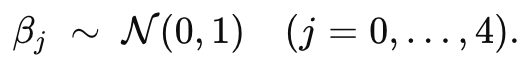

Full Posterior

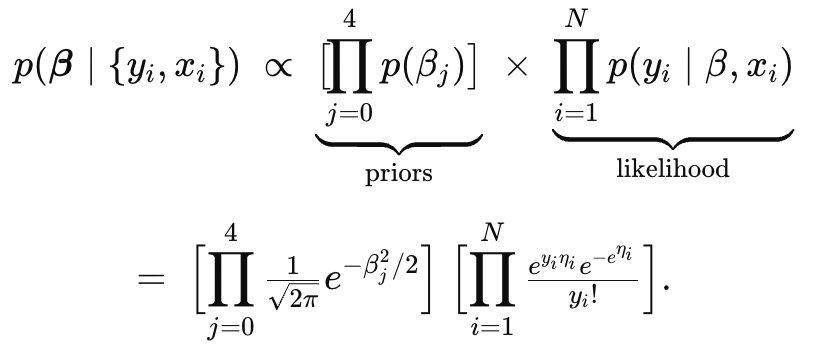

Posterior mean and expected cart size for a new order, where S is samples draw

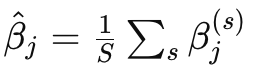
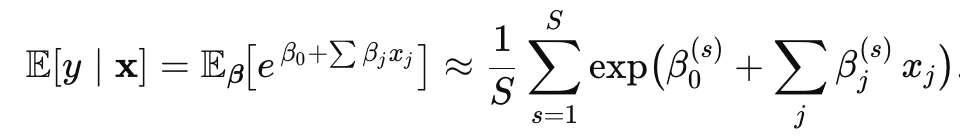

Predictive Distribution

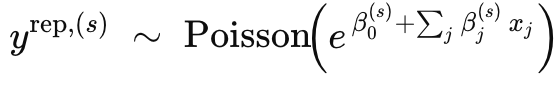

In [110]:
stan_d_pois = {
    "N": len(cart_df),
    "y": cart_df["cart_size"].values.astype(int),
    "x1": cart_df["order_number"].values.astype(float), 
    "x2": cart_df["order_dow"].values.astype(float),
    "x3": cart_df["order_hour_of_day"].values.astype(float),
    "x4": cart_df["avg_cart_size"].values.astype(float),  
}

In [99]:
# Parameter Standardization
for name in ["x1","x2","x3","x4"]:
    arr = stan_d_pois[name]
    stan_d_pois[name] = (arr - np.mean(arr)) / np.std(arr)

pois_model  = CmdStanModel(stan_file="poisson_reg.stan")

stan_d_pois["y"] = cart_df.cart_size.values.astype(int)
fit_pois = pois_model.sample(
    data=stan_d_pois,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    adapt_delta=0.99,
    max_treedepth=15
)
print("===== Poisson Regression Diagnostics =====")
print(fit_pois.diagnose())

20:09:45 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:09:58 - cmdstanpy - INFO - CmdStan done processing.



===== Poisson Regression Diagnostics =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [100]:
print(fit_pois.summary())

                Mean      MCSE    StdDev       MAD             5%  \
lp__   161065.000000  0.036794  1.608010  1.482600  161062.000000   
beta0       2.679970  0.000070  0.003876  0.003929       2.673570   
beta1       0.000949  0.000061  0.003515  0.003530      -0.004857   
beta2      -0.005744  0.000057  0.003433  0.003343      -0.011320   
beta3      -0.000809  0.000052  0.003406  0.003421      -0.006267   
beta4       0.455478  0.000047  0.002776  0.002737       0.450989   

                 50%            95%  ESS_bulk  ESS_tail    R_hat  
lp__   161065.000000  161067.000000   1932.36   2374.68  1.00068  
beta0       2.680060       2.686120   3052.37   2718.65  1.00019  
beta1       0.000924       0.006665   3386.91   2069.60  1.00160  
beta2      -0.005760      -0.000034   3700.39   2436.48  0.99998  
beta3      -0.000827       0.004903   4266.16   3330.63  1.00159  
beta4       0.455437       0.460088   3507.63   2918.85  1.00001  


- beta0 - `Intercept` on log-count, evaluated at average predictors. exp(2.68) ≈ 14.6 is expected cart size when all predictors are at their mean
- beta1 - Effect of one-SD increase in `order_number` on log(lambda). Essentially zero-order position has almost no effect on cart size
- beta2 - Effect of one-SD increase in `day_of_week`. Slight negative, but credible interval includes zero - no strong day-of-week effect
- beta3 - Effect of `hour_of_day`. Again essentially zero, so time-of-day doesn't shift cart size much
- beta4 - Effect of `avg_cart_size`. One-SD increase in avg_cart multiples expected count by exp(0.455) ≈ 1.57.

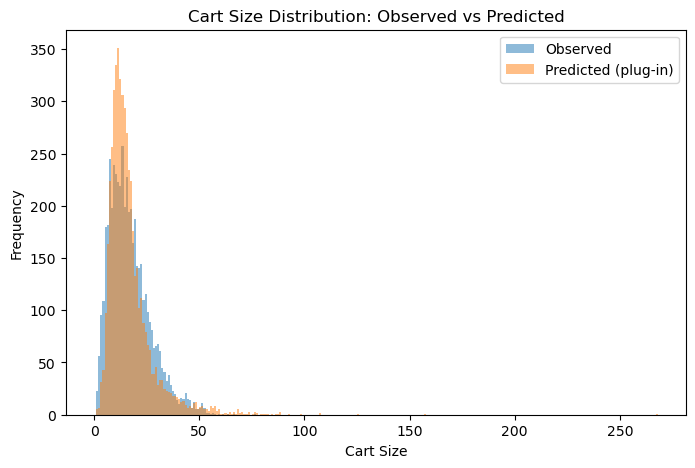

In [104]:
# -- Posterior predictive distribution vs. observed --

# Compute posterior means for each coefficient
beta_means = {name: np.mean(fit_pois.stan_variable(name)) for name in coef_names}

# Extract standardized predictors from stan_data
x1 = stan_d_pois['x1']
x2 = stan_d_pois['x2']
x3 = stan_d_pois['x3']
x4 = stan_d_pois['x4']

# Linear predictor using posterior means
eta = (beta_means['beta0']
       + beta_means['beta1'] * x1
       + beta_means['beta2'] * x2
       + beta_means['beta3'] * x3
       + beta_means['beta4'] * x4)

# Expected count
lam = np.exp(eta)

# Simulate posterior-predictive
y_pred = np.random.poisson(lam)

plt.figure(figsize=(8, 5))
plt.hist(cart_df['cart_size'], bins=range(0, int(cart_df['cart_size'].max()+1)), 
         alpha=0.5, label='Observed')
plt.hist(y_pred, bins=range(0, int(y_pred.max()+1)), 
         alpha=0.5, label='Predicted')
plt.legend()
plt.title('Cart Size Distribution: Observed vs Predicted')
plt.xlabel('Cart Size')
plt.ylabel('Frequency')
plt.show()

Posterior predictive draw: for each order i, we took the posterior mean of each ßj, computed

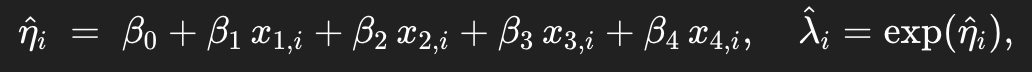

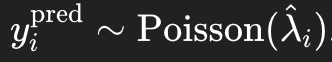

### What's the probability the cart size is k items?

In [119]:
order_number    = 5    # 5th order
order_dow       = 2    # Wednesday
order_hour      = 15   # 3 PM
avg_cart_size   = 12.3 # that user’s average basket size

x1 = (order_number - stan_d_pois['x1'].mean()) / stan_d_pois['x1'].std()
x2 = (order_dow     - stan_d_pois['x2'].mean()) / stan_d_pois['x2'].std()
x3 = (order_hour    - stan_d_pois['x3'].mean()) / stan_d_pois['x3'].std()
x4 = (avg_cart_size - stan_d_pois['x4'].mean()) / stan_d_pois['x4'].std()

# Posterior draws of the betas from your CmdStanPy fit
post = fit_pois.draws_pd()  
b0 = post['beta0'].values
b1 = post['beta1'].values
b2 = post['beta2'].values
b3 = post['beta3'].values
b4 = post['beta4'].values

# Compute λ for each draw and simulate
eta_draws    = b0 + b1*x1 + b2*x2 + b3*x3 + b4*x4
lambda_draws = np.exp(eta_draws)

# Posterior‐mean expected cart size
expected_size = lambda_draws.mean()

# Predictive interval (95%)
y_pred_draws  = np.random.poisson(lambda_draws)
ci_lower, ci_upper = np.percentile(y_pred_draws, [2.5, 97.5])

# Probability of exactly k items
k = 10
pmf_k = np.exp(-lambda_draws) * (lambda_draws**k) / math.factorial(k)
prob_k = pmf_k.mean()

print(f"Expected cart size     = {expected_size:.2f} items")
print(f"95% predictive interval = [{ci_lower:.0f}, {ci_upper:.0f}] items")
print(f"P(cart_size = {k})       = {prob_k:.3f}")


Expected cart size     = 12.01 items
95% predictive interval = [6, 19] items
P(cart_size = 10)       = 0.105


#### Model Comparison (ML and Bayesian)

In [123]:
# REORDER PROB
X = model_l[['order_number', 'order_dow', 'order_hour_of_day']]
y = model_l['reordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

model_logistic = LogisticRegression(max_iter = 300)
model_logistic.fit(X_train, y_train)
y_prob = model_logistic.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_prob > 0.5)
auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)

print('===== Logistic Regression =====')
print(f'Accuracy: {acc:.3f}')
print(f'AUC Score: {auc:.3f}')
print(f'Logloss: {logloss:.3f}')

# CART SIZE PROB
X_reg = cart_df[['order_number', 'order_dow', 'order_hour_of_day', 'avg_cart_size']]
y_reg = cart_df['cart_size']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
model_poisson = PoissonRegressor(alpha=1e-6, max_iter=300)
model_poisson.fit(Xr_train, yr_train)
y_pred_poisson = model_poisson.predict(Xr_test)

rmse_pois = mean_squared_error(yr_test, y_pred_poisson, squared=False)
mae_pois  = mean_absolute_error(   yr_test, y_pred_poisson)

print("===== Poisson Regression =====")
print(f"RMSE: {rmse_pois:.2f}")
print(f"MAE: {mae_pois:.2f}")

===== Logistic Regression =====
Accuracy: 0.615
AUC Score: 0.673
Logloss: 0.643
===== Poisson Regression =====
RMSE: 3.67
MAE: 2.46


In [130]:
alpha_draws   = fit.stan_variable('alpha')         
gamma_u_draws = fit.stan_variable('gamma_u')       
delta_p_draws = fit.stan_variable('delta_p')       
beta_num_draws  = fit.stan_variable('beta_num')    
beta_dow_draws  = fit.stan_variable('beta_dow')
beta_hour_draws = fit.stan_variable('beta_hour')

df_test = model_l.sample(frac = 0.3, random_state = 42)
u_idx_test = df_test['user_idx'].values.astype(int)
p_idx_test = df_test['product_idx'].values.astype(int)
num_test   = df_test['order_number'].values
dow_test   = df_test['order_dow'].values
hr_test    = df_test['order_hour_of_day'].values
y_test     = df_test['reordered'].values

logits = (
    alpha_draws[:, None]
    + gamma_u_draws[:, u_idx_test]
    + delta_p_draws[:, p_idx_test]
    + beta_num_draws[:, None]  * num_test[None, :]
    + beta_dow_draws[:, None]  * dow_test[None, :]
    + beta_hour_draws[:, None] * hr_test[None, :]
)

probs = 1 / (1 + np.exp(-logits))  
prob_means = probs.mean(axis=0)  

# Compute metrics
accuracy_hier = accuracy_score(y_test, prob_means > 0.5)
auc_hier      = roc_auc_score(y_test, prob_means)
logloss_hier  = log_loss(y_test, prob_means)

print("=== Hierarchical Logistic Regression ===")
print(f"Accuracy: {accuracy_hier:.3f}")
print(f"AUC: {auc_hier:.3f}")
print(f"LogLoss: {logloss_hier:.3f}")

=== Hierarchical Logistic Regression ===
Accuracy: 0.591
AUC: 0.719
LogLoss: 3.323


In [135]:
X = cart_df[['order_number','order_dow','order_hour_of_day','avg_cart_size']]
y = cart_df['cart_size']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
means = X_train.mean()
stds  = X_train.std()

X_train_std = (X_train - means) / stds
X_test_std  = (X_test  - means) / stds


x1_test = X_test_std['order_number'].values
x2_test = X_test_std['order_dow'].values
x3_test = X_test_std['order_hour_of_day'].values
x4_test = X_test_std['avg_cart_size'].values

b0 = fit_pois.stan_variable('beta0') 
b1 = fit_pois.stan_variable('beta1')
b2 = fit_pois.stan_variable('beta2')
b3 = fit_pois.stan_variable('beta3')
b4 = fit_pois.stan_variable('beta4')

eta = (
      b0[:, None]
    + b1[:, None] * x1_test[None, :]
    + b2[:, None] * x2_test[None, :]
    + b3[:, None] * x3_test[None, :]
    + b4[:, None] * x4_test[None, :]
)
lambda_draws = np.exp(eta)

# Posterior-mean prediction for each test point
y_pred_mean = lambda_draws.mean(axis=0)

rmse = mean_squared_error(y_test, y_pred_mean, squared=False)
mae  = mean_absolute_error(y_test, y_pred_mean)

print("Bayesian Poisson Regression")
print(f"RMSE = {rmse:.2f}")
print(f"MAE  = {mae:.2f}")


Bayesian Poisson Regression (held-out test)
RMSE = 3.71
MAE  = 2.48
